# Hyperparameter Optimization & Training Analysis

### Evaluating Optuna trials and final model 

This notebook analyzes the **`acne_hparam_search_v1`** study and the final training run using the best parameters.

**WARNING!** DO NOT RUN THIS NOTEBOOK!

I have recently changed the folder structure (migrated notebooks/), and the paths in this file have not been updated yet. This version is for review only.

DO NOT COPY THIS FILE. A new, corrected version for production use and copying is be available under the name: `yolo_analysis_v2.ipynb`

# Hyperparameter Optimization Analysis

In [1]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from config import RUNS_DIR

STUDY_PREFIX = "acne_hparam_search_v1_trial_"

In [2]:
# LOAD TRIALS 

records = []

for trial_dir in RUNS_DIR.glob(f"{STUDY_PREFIX}*"):

    args_path = trial_dir / "args.yaml"
    results_path = trial_dir / "results.csv"

    if not args_path.exists() or not results_path.exists():
        continue

    # Load params
    with open(args_path, "r") as f:
        args = yaml.safe_load(f)

    # Load metrics
    df = pd.read_csv(results_path)

    if df.empty:
        continue

    final_row = df.iloc[-1]

    record = {
        "trial": trial_dir.name,
        "map50": final_row.get("metrics/mAP50(B)", None),
        "map50_95": final_row.get("metrics/mAP50-95(B)", None),
        "precision": final_row.get("metrics/precision(B)", None),
        "recall": final_row.get("metrics/recall(B)", None),

        "optimizer": args.get("optimizer"),
        "lr0": args.get("lr0"),
        "weight_decay": args.get("weight_decay"),
        "mosaic": args.get("mosaic"),
        "mixup": args.get("mixup"),
        "hsv_s": args.get("hsv_s"),
        "hsv_v": args.get("hsv_v"),
        "scale": args.get("scale"),
    }

    records.append(record)

results = pd.DataFrame(records)

In [ ]:
print(f"Loaded {len(results)} trials")
results.sort_values("map50_95", ascending=False).head()

Loaded 14 trials


,trial,map50,map50_95,precision,recall,optimizer,lr0,weight_decay,mosaic,mixup,hsv_s,hsv_v,scale
8,acne_hparam_search_v1_trial_3,0.37981,0.13265,0.48673,0.38801,AdamW,0.000938,0.000024,0.525313,0.036816,0.269225,0.360626,0.203803
4,acne_hparam_search_v1_trial_14,0.36483,0.12473,0.44828,0.38252,AdamW,0.001548,0.000040,0.435319,0.049916,0.260411,0.140821,0.496113
3,acne_hparam_search_v1_trial_13,0.36288,0.12303,0.44486,0.37942,AdamW,0.003998,0.000070,0.553605,0.036032,0.595933,0.276048,0.234809
9,acne_hparam_search_v1_trial_4,0.33094,0.10836,0.42016,0.36796,AdamW,0.000128,0.000246,0.476542,0.006449,0.450295,0.186488,0.526756
13,acne_hparam_search_v1_trial_8,0.32169,0.10646,0.40330,0.37249,SGD,0.001099,0.000339,0.415749,0.023237,0.313074,0.452584,0.291642


In [ ]:
# Correlation with target metric (map50_95) 

numeric_cols = [
    "lr0",
    "weight_decay",
    "mosaic",
    "mixup",
    "hsv_s",
    "hsv_v",
    "scale",
    "map50_95"
]

corr = results[numeric_cols].corr()

corr["map50_95"].sort_values(ascending=False)

map50_95        1.000000
hsv_s           0.372346
lr0             0.336151
mixup           0.293976
mosaic          0.274688
hsv_v           0.115929
scale           0.070915
weight_decay   -0.062712
Name: map50_95, dtype: float64

In [ ]:
# Best trial
best = results.sort_values("map50_95", ascending=False).iloc[0]
print(best)

trial           acne_hparam_search_v1_trial_3
map50                                 0.37981
map50_95                              0.13265
precision                             0.48673
recall                                0.38801
optimizer                               AdamW
lr0                                  0.000938
weight_decay                         0.000024
mosaic                               0.525313
mixup                                0.036816
hsv_s                                0.269225
hsv_v                                0.360626
scale                                0.203803
Name: 8, dtype: object


# Final Model Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from config import RUNS_DIR

run_name = "acne_train_production_v1"

In [ ]:
run_dir = RUNS_DIR / run_name
results_file = run_dir / "results.csv"

if not results_file.exists():
    raise FileNotFoundError(f"Missing: {results_file}")

df = pd.read_csv(results_file)


df.columns = df.columns.str.strip()

print("Available columns:")
print(df.columns.tolist())

print(f"\nEpochs trained: {len(df)}")

Available columns:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

Epochs trained: 150


BEST EPOCH

epoch with best detection quality (highest mAP50-95)

In [ ]:
best_epoch = df["metrics/mAP50-95(B)"].idxmax()

print(f"Best epoch: {best_epoch}")

df.loc[best_epoch, [
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)"
]]

Best epoch: 149


metrics/precision(B)    0.59346
metrics/recall(B)       0.45272
metrics/mAP50(B)        0.44992
metrics/mAP50-95(B)     0.18746
Name: 149, dtype: float64

LOSS CURVES

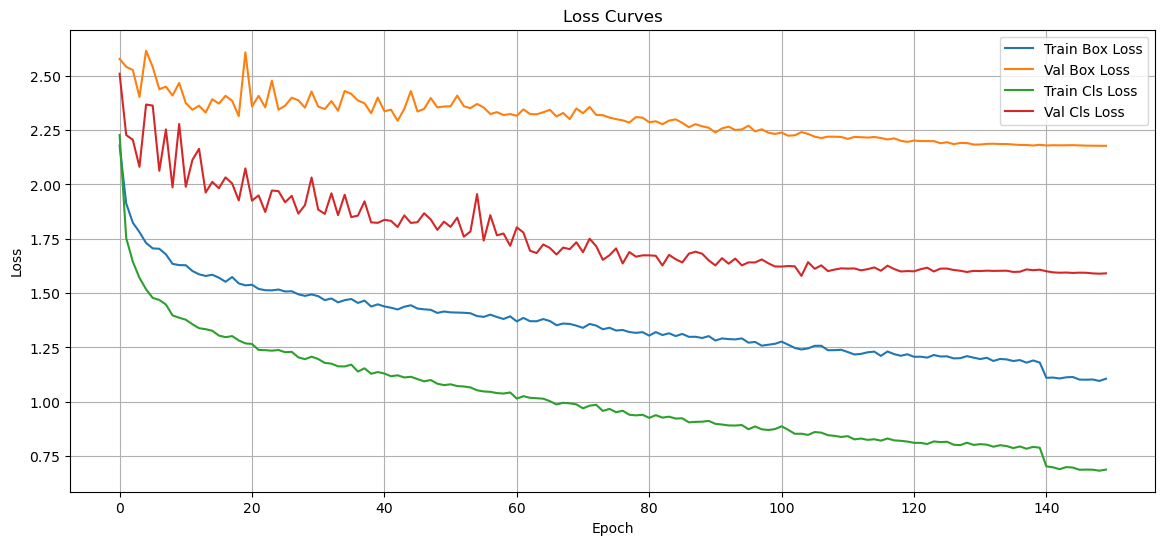

In [ ]:
plt.figure(figsize=(14, 6))

# Training vs validation losses:
# box loss -> bounding box regression error
# cls loss -> classification error

# Big differences between train and val may indicate overfitting

plt.plot(df["train/box_loss"], label="Train Box Loss")
plt.plot(df["val/box_loss"], label="Val Box Loss")
plt.plot(df["train/cls_loss"], label="Train Cls Loss")
plt.plot(df["val/cls_loss"], label="Val Cls Loss")

plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# All curves go down -> good
# high distance between Train and Val -> model is too focused on the training set 

MAIN METRICS

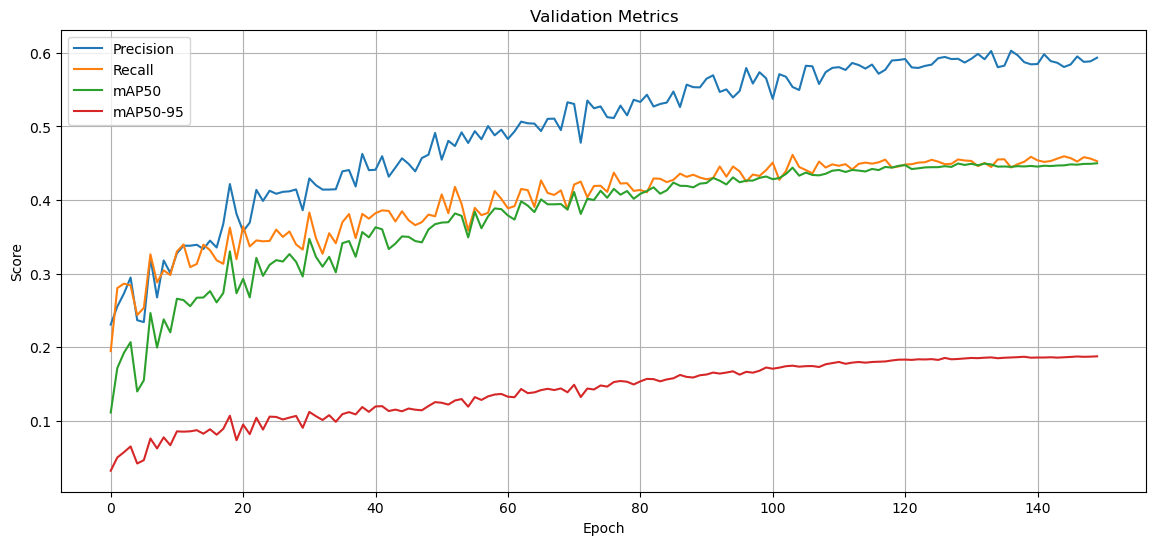

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(df["metrics/precision(B)"], label="Precision")
plt.plot(df["metrics/recall(B)"], label="Recall")
plt.plot(df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["metrics/mAP50-95(B)"], label="mAP50-95")

plt.title("Validation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

# model is good at being right (Precision) (not a lot of FP)
# too cautious, misses many spots (Recall) (Most important to improve)
# has trouble drawing the boxes perfectly (not so important for now)

LEARNING RATE

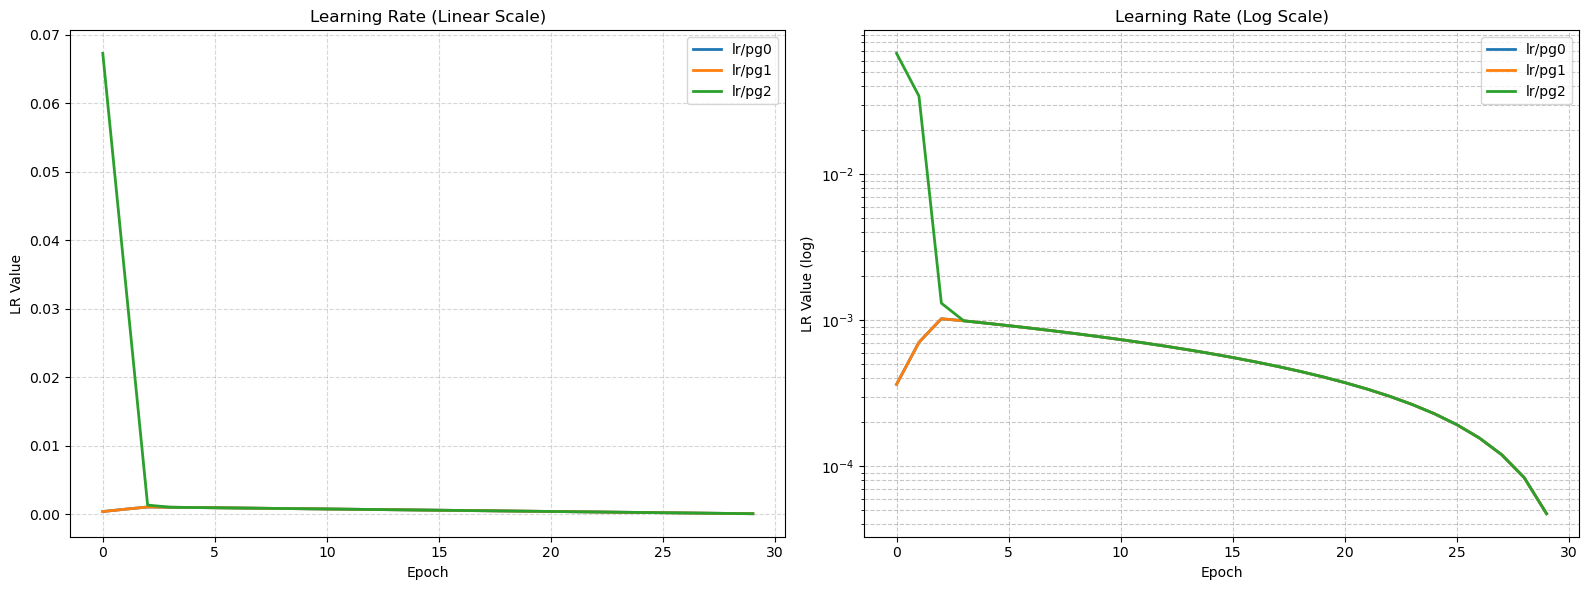

In [ ]:
import matplotlib.pyplot as plt

# Learning rate schedule
lr_cols = [c for c in df.columns if "lr/" in c]

if lr_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for col in lr_cols:
        ax1.plot(df[col], label=col, linewidth=2)
        ax2.plot(df[col], label=col, linewidth=2)

    ax1.set_title("Learning Rate (Linear Scale)")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("LR Value")
    ax1.grid(True, which="both", linestyle='--', alpha=0.5)
    ax1.legend()

    ax2.set_yscale('log')
    ax2.set_title("Learning Rate (Log Scale)")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("LR Value (log)")
    ax2.grid(True, which="both", linestyle='--', alpha=0.7)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # The Warmup and smooth curve show the training speed was good 
    # This helped the model learn the basics first and then focus on the details

GENERALIZATION GAP

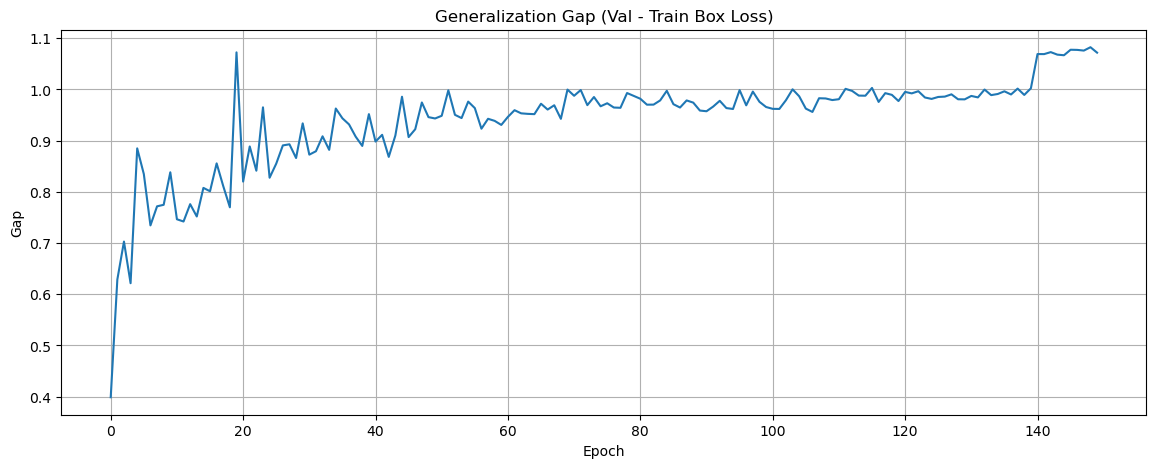

In [ ]:
# Difference between validation and training loss
# Positive gap -> possible overfitting
# Stable/low gap -> good generalization

if "train/box_loss" in df.columns and "val/box_loss" in df.columns:
    gap = df["val/box_loss"] - df["train/box_loss"]

    plt.figure(figsize=(14, 5))
    plt.plot(gap)

    plt.title("Generalization Gap (Val - Train Box Loss)")
    plt.xlabel("Epoch")
    plt.ylabel("Gap")
    plt.grid(True)
    plt.show()

    # TOO BIG - SHOULD BE 0.1 - 0.3 
    # model memorized the training photos instead of learning (data leakage!!!)